In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
dataset_df = pd.read_csv('../Source/HAM10000_metadata_part1.csv')
dataset_df.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,cell_type,cell_type_idx
0,HAM_0007180,ISIC_0033272,mel,histo,65.0,male,face,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanoma,5
1,HAM_0007195,ISIC_0031923,nv,histo,40.0,female,lower extremity,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanocytic nevi,4
2,HAM_0001835,ISIC_0026652,mel,histo,65.0,male,back,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanoma,5
3,HAM_0000465,ISIC_0030583,bkl,consensus,35.0,female,trunk,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Benign keratosis-like lesions,2
4,HAM_0001720,ISIC_0034010,nv,histo,45.0,male,abdomen,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanocytic nevi,4
5,HAM_0006333,ISIC_0024424,nv,histo,35.0,male,trunk,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanocytic nevi,4
6,HAM_0004548,ISIC_0032832,nv,histo,45.0,female,upper extremity,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanocytic nevi,4
7,HAM_0006526,ISIC_0026671,nv,histo,55.0,male,lower extremity,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanocytic nevi,4
8,HAM_0003102,ISIC_0032389,mel,histo,65.0,male,face,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanoma,5
9,HAM_0004260,ISIC_0025525,nv,histo,65.0,male,back,C://Users//Amreet//Desktop//Skin-Cancer-Classi...,Melanocytic nevi,4


In [3]:
dataset_df['age'].fillna((dataset_df['age'].mean()), inplace=True)   # Replacing all the missing values with the mean values

# checking again for the missing values present or not
dataset_df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age              0
sex              0
localization     0
image_path       0
cell_type        0
cell_type_idx    0
dtype: int64

In [4]:
from sklearn.utils import resample
df_bkl = dataset_df[dataset_df['dx']=='bkl']
df_nv = dataset_df[dataset_df['dx']=='nv']
df_df = dataset_df[dataset_df['dx']=='df']
df_mel = dataset_df[dataset_df['dx']=='mel']
df_vasc = dataset_df[dataset_df['dx']=='vasc']
df_bcc = dataset_df[dataset_df['dx']=='bcc']
df_akiec = dataset_df[dataset_df['dx']=='akiec']
n_samples = 500
df_bkl_balanced = resample(df_bkl, replace =True, n_samples=n_samples, random_state=42)
df_nv_balanced = resample(df_nv, replace =True, n_samples=n_samples, random_state=42)
df_df_balanced = resample(df_df, replace =True, n_samples=n_samples, random_state=42)
df_mel_balanced = resample(df_mel, replace =True, n_samples=n_samples, random_state=42)
df_vasc_balanced = resample(df_vasc, replace =True, n_samples=n_samples, random_state=42)
df_bcc_balanced = resample(df_bcc, replace =True, n_samples=n_samples, random_state=42)
df_akiec_balanced = resample(df_akiec, replace =True, n_samples=n_samples, random_state=42)

disease_df = pd.concat([df_bkl_balanced, df_nv_balanced, df_df_balanced, df_mel_balanced, df_vasc_balanced, df_bcc_balanced, df_akiec_balanced])

print("Details regarding the Dataset")
disease_df.info()
print("Shape of the Dataset -- ",disease_df.shape)

Details regarding the Dataset
<class 'pandas.core.frame.DataFrame'>
Int64Index: 3500 entries, 824 to 4521
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lesion_id      3500 non-null   object 
 1   image_id       3500 non-null   object 
 2   dx             3500 non-null   object 
 3   dx_type        3500 non-null   object 
 4   age            3500 non-null   float64
 5   sex            3500 non-null   object 
 6   localization   3500 non-null   object 
 7   image_path     3500 non-null   object 
 8   cell_type      3500 non-null   object 
 9   cell_type_idx  3500 non-null   int64  
dtypes: float64(1), int64(1), object(8)
memory usage: 300.8+ KB
Shape of the Dataset --  (3500, 10)


In [5]:
from PIL import Image
import sklearn as sk
from sklearn import preprocessing
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.metrics import roc_auc_score

In [6]:
from PIL import Image
disease_df['image'] = disease_df['image_path'].map(lambda x: np.asarray(Image.open(x).resize((160,120))))

In [7]:
print(disease_df['image'].map(lambda x: x.shape))

824     (120, 160, 3)
3837    (120, 160, 3)
2363    (120, 160, 3)
892     (120, 160, 3)
606     (120, 160, 3)
            ...      
3115    (120, 160, 3)
855     (120, 160, 3)
2979    (120, 160, 3)
4576    (120, 160, 3)
4521    (120, 160, 3)
Name: image, Length: 3500, dtype: object


In [8]:
rgb_disease_df = disease_df.apply(lambda x: pd.Series({'{}_mean'.format(k): v for k, v in 
                                  zip(['Red', 'Green', 'Blue'], 
                                      np.mean(x['image'], (0, 1)))}),1)
gray_col_vec = rgb_disease_df.apply(lambda x: np.mean(x), 1)
for c_col in rgb_disease_df.columns:
    rgb_disease_df[c_col] = rgb_disease_df[c_col]/gray_col_vec
rgb_disease_df['Gray_mean'] = gray_col_vec
rgb_disease_df.sample(10)

,Red_mean,Green_mean,Blue_mean,Gray_mean
176,1.090039,0.913156,0.996805,150.345573
3735,1.060141,0.912170,1.027689,137.083733
811,1.158221,0.940899,0.900880,156.020642
3383,1.070685,0.913022,1.016293,159.663611
3412,1.108418,0.918050,0.973532,173.850625
2833,1.144017,0.889910,0.966074,153.398542
2987,1.044773,0.951531,1.003696,174.509583
3067,1.144823,0.872874,0.982303,190.737396
3423,1.111535,0.905673,0.982792,181.063125
3505,1.194874,0.860984,0.944142,166.966406


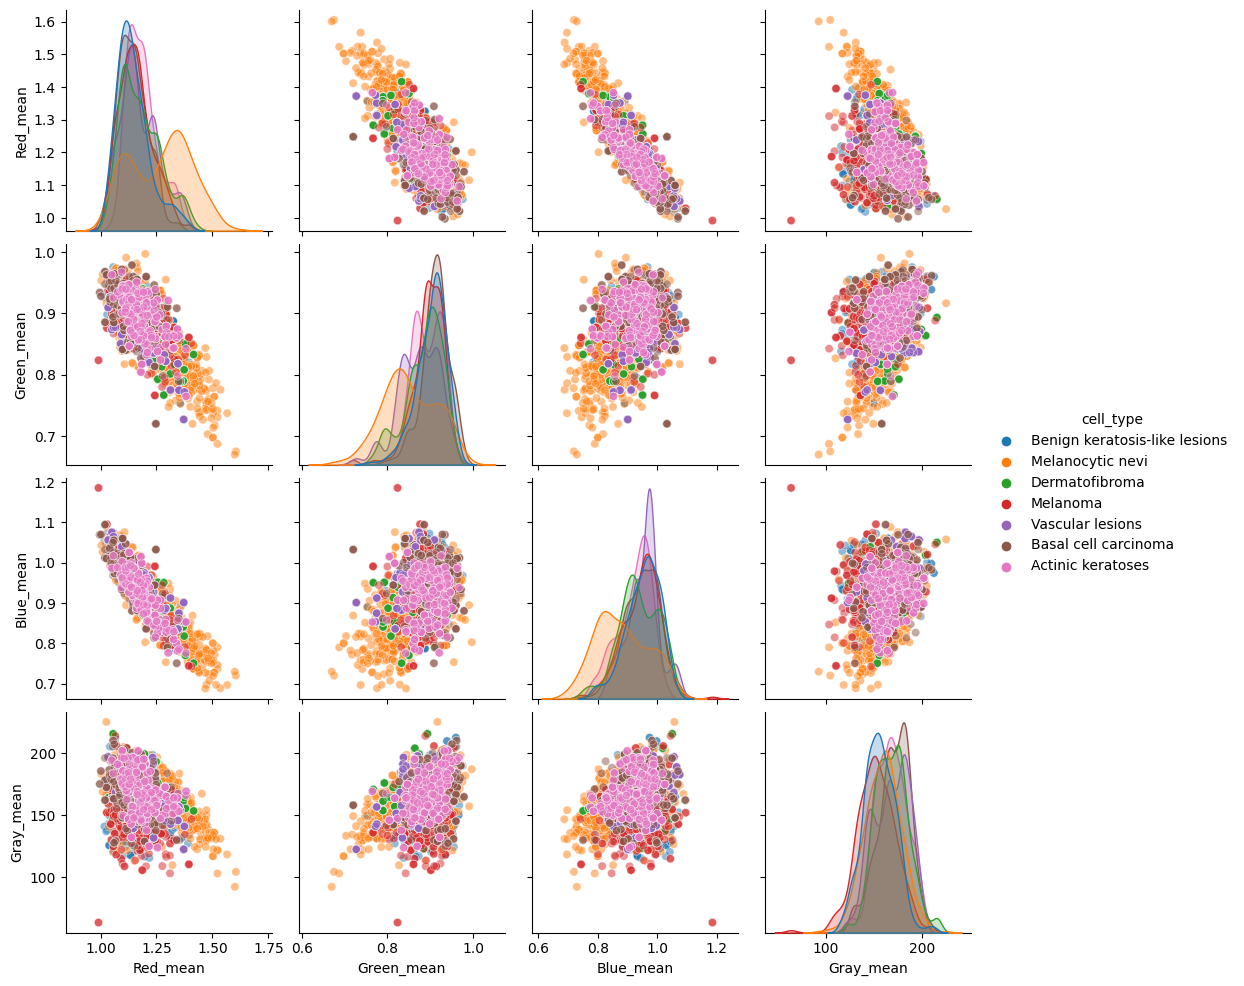

In [9]:
for c_col in rgb_disease_df.columns:
    disease_df[c_col] = rgb_disease_df[c_col].values
sns.pairplot(disease_df[['Red_mean', 'Green_mean', 'Blue_mean', 'Gray_mean', 'cell_type']], 
             hue='cell_type', plot_kws = {'alpha': 0.5})

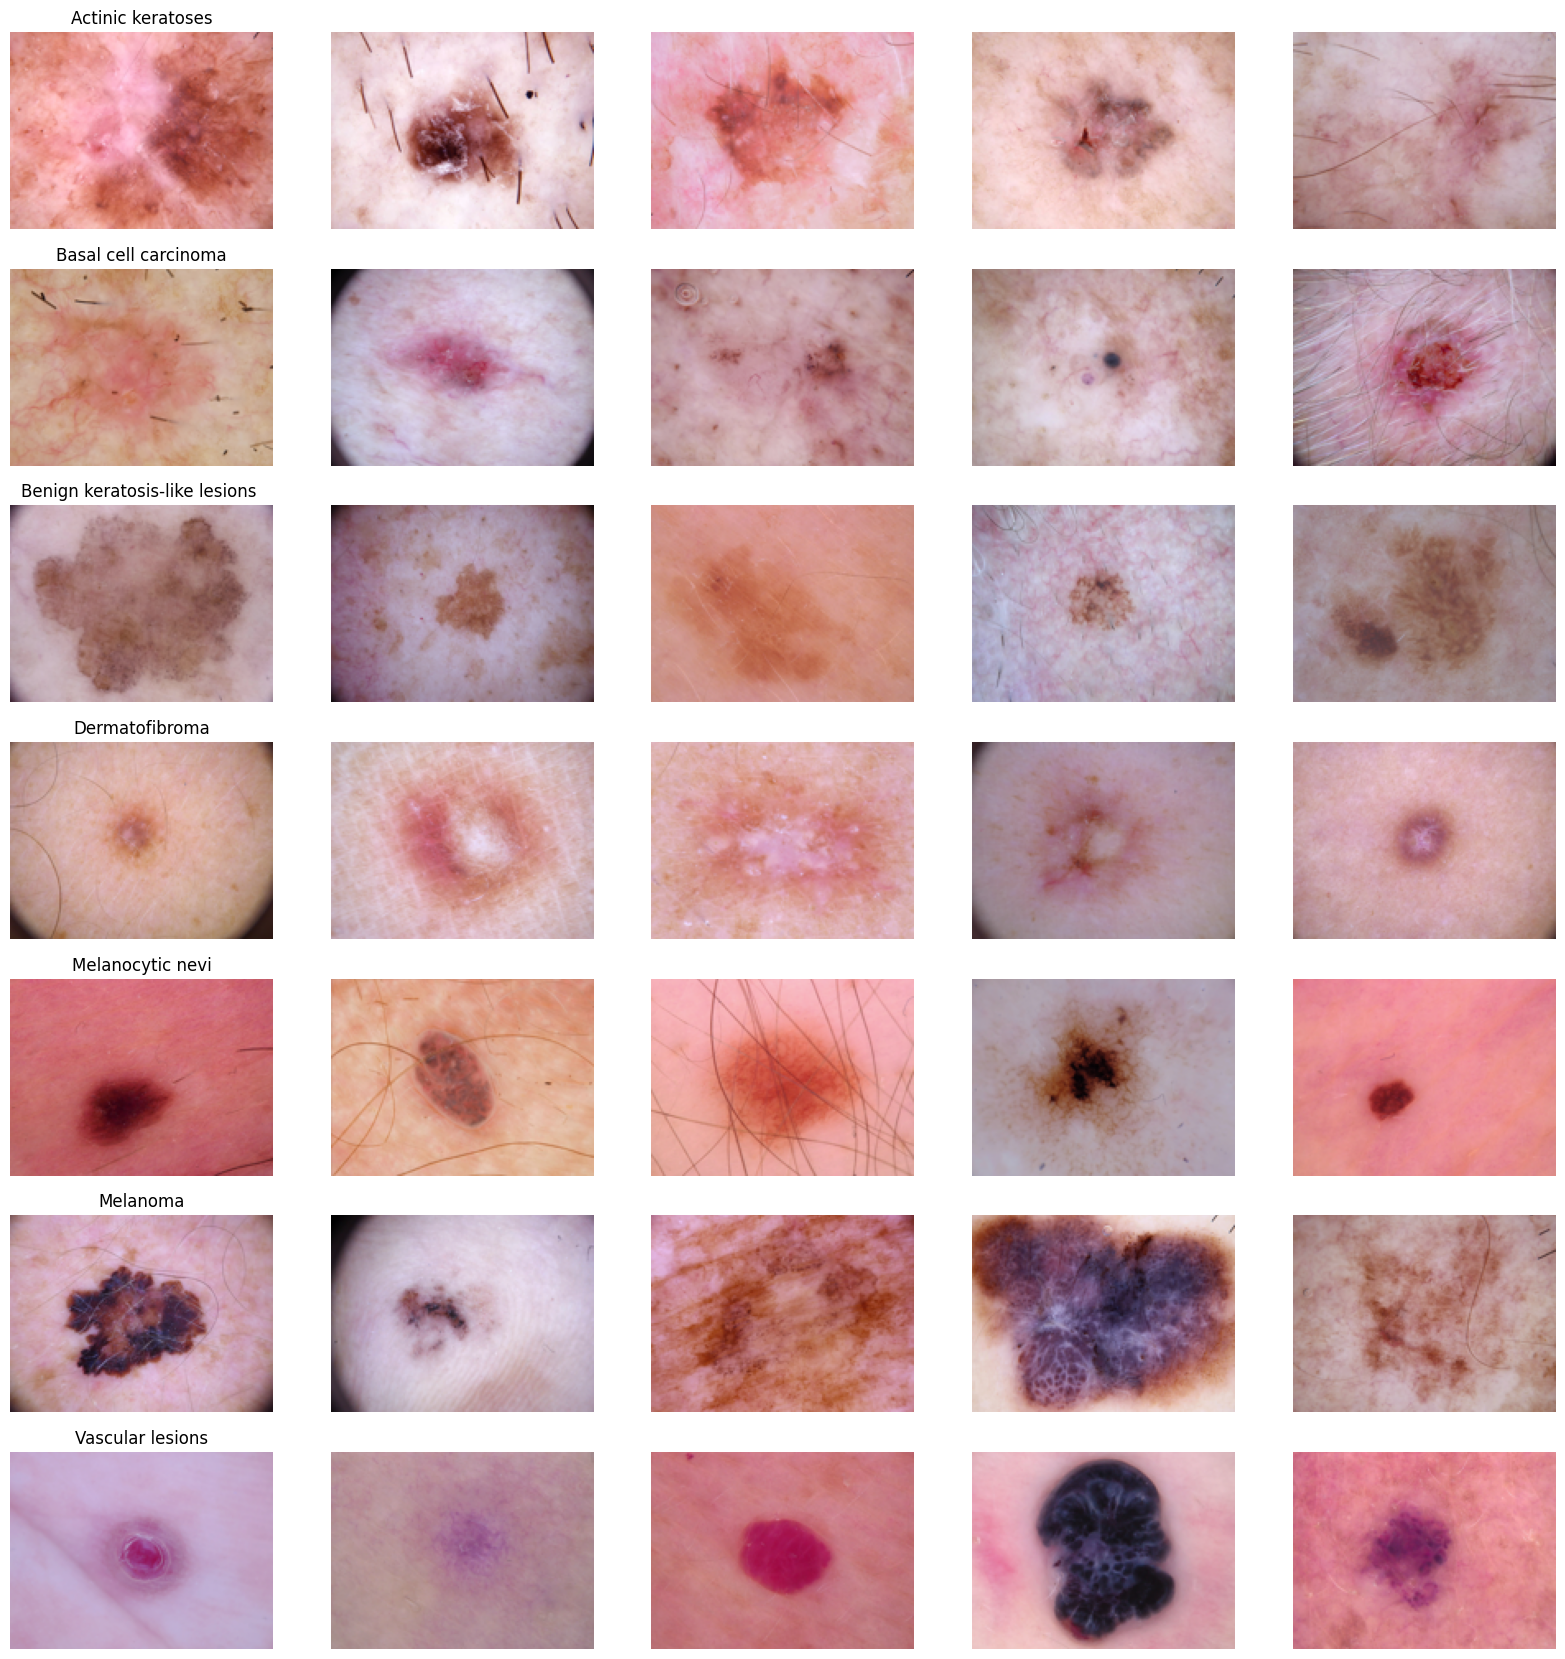

In [10]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, disease_df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')

In [11]:
disease_df['image'].map(lambda x: x.shape).value_counts()

(120, 160, 3)    3500
Name: image, dtype: int64

In [12]:
features=disease_df.drop(columns=['cell_type_idx'],axis=1)  # removing the column from the dataset
target=disease_df['cell_type_idx']                          # setting that column as the target variable

In [13]:
from sklearn.model_selection import train_test_split
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(features, target, test_size=0.20,random_state=1234)
# Training is 80 % and testing is 20 %

In [14]:
x_train = np.asarray(x_train_1['image'].tolist())
x_test = np.asarray(x_test_1['image'].tolist())

x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

In [15]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train_1, num_classes = 7)
y_test = to_categorical(y_test_1, num_classes = 7)

In [16]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = 0.13, random_state = 2)

In [17]:
# Reshape image in 3 dimensions (height = 128px, width = 128px , num_channels = 3)
x_train = x_train.reshape(x_train.shape[0], *(120, 160, 3))
x_test = x_test.reshape(x_test.shape[0], *(120, 160, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(120, 160, 3))

In [18]:
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Input, Lambda, Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings("ignore",category = FutureWarning)

In [19]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.regularizers import l2

In [20]:
# Set the GPU device
import tensorflow as tf
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    tf.config.experimental.set_visible_devices(physical_devices[0], 'GPU')

In [21]:
IMAGE_SIZE = [120, 160]
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [22]:
vgg.input

<KerasTensor: shape=(None, 120, 160, 3) dtype=float32 (created by layer 'input_1')>

In [23]:
vgg.output

<KerasTensor: shape=(None, 3, 5, 512) dtype=float32 (created by layer 'block5_pool')>

In [24]:
for layer in vgg.layers:
  layer.trainable = False

In [25]:
last_layer = vgg.get_layer('block5_pool')
print('last layer output shape:', last_layer.output_shape)
last_output = last_layer.output

last layer output shape: (None, 3, 5, 512)


In [26]:
from keras import layers
# Flatten the output layer to 1 dimension
x = layers.GlobalMaxPooling2D()(last_output)
# Add a fully connected layer with 512 hidden units and ReLU activation
x = layers.Dense(512, activation='relu')(x)
# Add a dropout rate of 0.5
x = layers.Dropout(0.5)(x)
# Add a final sigmoid layer for classification
x = layers.Dense(7, activation='softmax')(x)

In [27]:
# Configure and compile the model
from tensorflow.keras.optimizers import Adam
model = Model(vgg.input, x)
optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=True)
model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

In [28]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 120, 160, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 120, 160, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 120, 160, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 60, 80, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 60, 80, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 60, 80, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 30, 40, 128)       0     

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rotation_range=60, width_shift_range=0.2, height_shift_range=0.2,
                                   shear_range=0.2, zoom_range=0.2, fill_mode='nearest')

train_datagen.fit(x_train)

val_datagen = ImageDataGenerator()
val_datagen.fit(x_validate)

In [30]:
batch_size = 64
epochs = 3
history = model.fit_generator(train_datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = val_datagen.flow(x_validate, y_validate),
                              verbose = 1, steps_per_epoch=(x_train.shape[0] // batch_size), 
                              validation_steps=(x_validate.shape[0] // batch_size))

c:\Users\Amreet\anaconda3\envs\tensorflow22\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/3
38/38 [==============================] - 51s 722ms/step - loss: 2.3053 - accuracy: 0.1560 - val_loss: 1.8772 - val_accuracy: 0.2313
Epoch 2/3
38/38 [==============================] - 10s 269ms/step - loss: 1.9820 - accuracy: 0.2458 - val_loss: 1.6776 - val_accuracy: 0.3625
Epoch 3/3
38/38 [==============================] - 10s 268ms/step - loss: 1.7839 - accuracy: 0.3103 - val_loss: 1.5655 - val_accuracy: 0.4250


In [31]:
for layer in model.layers[:15]:
    layer.trainable = False

for layer in model.layers[15:]:
    layer.trainable = True

In [32]:
optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

In [33]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 120, 160, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 120, 160, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 120, 160, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 60, 80, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 60, 80, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 60, 80, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 30, 40, 128)       0     

In [34]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', patience=3, verbose=1, factor=0.5, 
                                            learning_rate=0.00001, cooldown=3)

In [35]:
batch_size = 64
epochs = 30
history = model.fit_generator(train_datagen.flow(x_train,y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = val_datagen.flow(x_validate, y_validate),
                              verbose = 1, steps_per_epoch=(x_train.shape[0] // batch_size),
                              validation_steps=(x_validate.shape[0] // batch_size), callbacks=[learning_rate_reduction])

Epoch 1/30
38/38 [==============================] - 13s 283ms/step - loss: 1.3979 - accuracy: 0.4675 - val_loss: 1.0359 - val_accuracy: 0.6250
Epoch 2/30
38/38 [==============================] - 11s 274ms/step - loss: 1.0422 - accuracy: 0.6134 - val_loss: 0.8829 - val_accuracy: 0.6938
Epoch 3/30
38/38 [==============================] - 11s 274ms/step - loss: 0.8686 - accuracy: 0.6775 - val_loss: 0.7772 - val_accuracy: 0.7375
Epoch 4/30
38/38 [==============================] - 11s 276ms/step - loss: 0.7500 - accuracy: 0.7234 - val_loss: 0.9423 - val_accuracy: 0.6500
Epoch 5/30
38/38 [==============================] - 11s 280ms/step - loss: 0.7283 - accuracy: 0.7255 - val_loss: 0.7772 - val_accuracy: 0.7625
Epoch 6/30
38/38 [==============================] - 11s 287ms/step - loss: 0.6008 - accuracy: 0.7820 - val_loss: 0.7107 - val_accuracy: 0.7563
Epoch 7/30
38/38 [==============================] - 11s 284ms/step - loss: 0.5232 - accuracy: 0.8069 - val_loss: 0.6366 - val_accuracy: 0.7812

<Axes: >

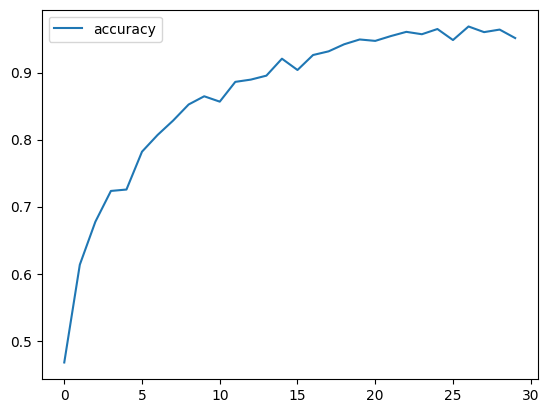

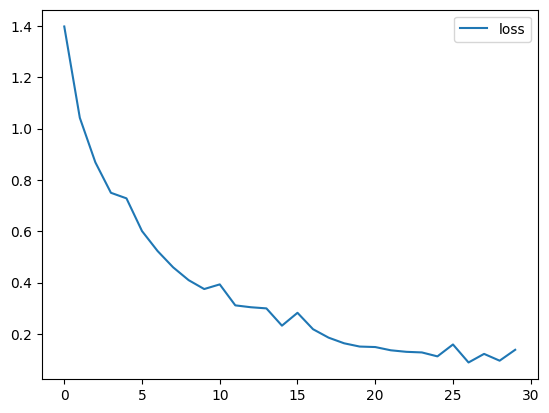

In [36]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['accuracy']].plot()
history_df.loc[:, ['loss']].plot()

In [37]:
scores = model.evaluate(x_test, y_test, verbose=2)

print('VGG-16 Error: %.2f%%' % ((100 - scores[1] * 100)))
print('VGG-16 Acc: %.2f%%' % (scores[1] * 100))
final_loss, final_acc = model.evaluate(x_test, y_test, verbose=0)
print("Final loss: {0:.4f}".format(final_loss))

y_pred = model.predict(x_test)

22/22 - 5s - loss: 0.5831 - accuracy: 0.8700
VGG-16 Error: 13.00%
VGG-16 Acc: 87.00%
Final loss: 0.5831


In [38]:
history_df.to_csv('../models/Reports/vgg_1_history_Adam11.csv')
model.save("../models/H5_Format/model_vgg_adam1.h5")

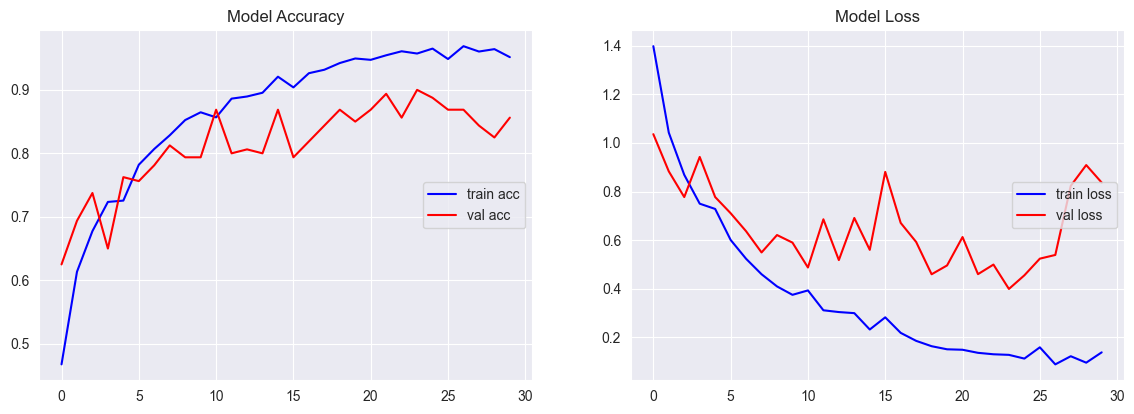

In [39]:
sns.set_style("darkgrid")
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
plt.plot(history.history['accuracy'], 'b', label="Training accuracy")
plt.plot(history.history['val_accuracy'], 'r', label="Validation accuracy")
plt.legend(['train acc', 'val acc'], loc='center right')
plt.title('Model Accuracy')

plt.subplot(2,2,2)
plt.plot(history.history['loss'], 'b', label= "Training loss")
plt.plot(history.history['val_loss'], 'r', label="validation loss")
plt.legend(['train loss', 'val loss'], loc='center right')
plt.title('Model Loss')
plt.show()

In [41]:
from tensorflow.keras.models import load_model
best_model = load_model('../models/H5_Format/model_vgg_adam1.h5')

# compute predictions
with tf.device('/GPU:0'):
    y_pred_prob = np.around(best_model.predict(x_test),7)
    y_pred = np.argmax(y_pred_prob,axis=1)

y_true = np.argmax(y_test, axis=1)

In [42]:
lesion_names = ['Melanocytic nevi','Melanoma','Benign keratosis-like lesions ',
               'Basal cell carcinoma','Actinic keratoses','Vascular lesions',
               'Dermatofibroma']

lesion_names_short = ['nv','mel','bkl','bcc','akiec','vasc','df']

targetNames = ['Actinic keratoses', 'Basal cell carcinoma','Benign keratosis-like lesions', 
                'Dermatofibroma','Melanocytic nevi','Melanoma','Vascular lesions']

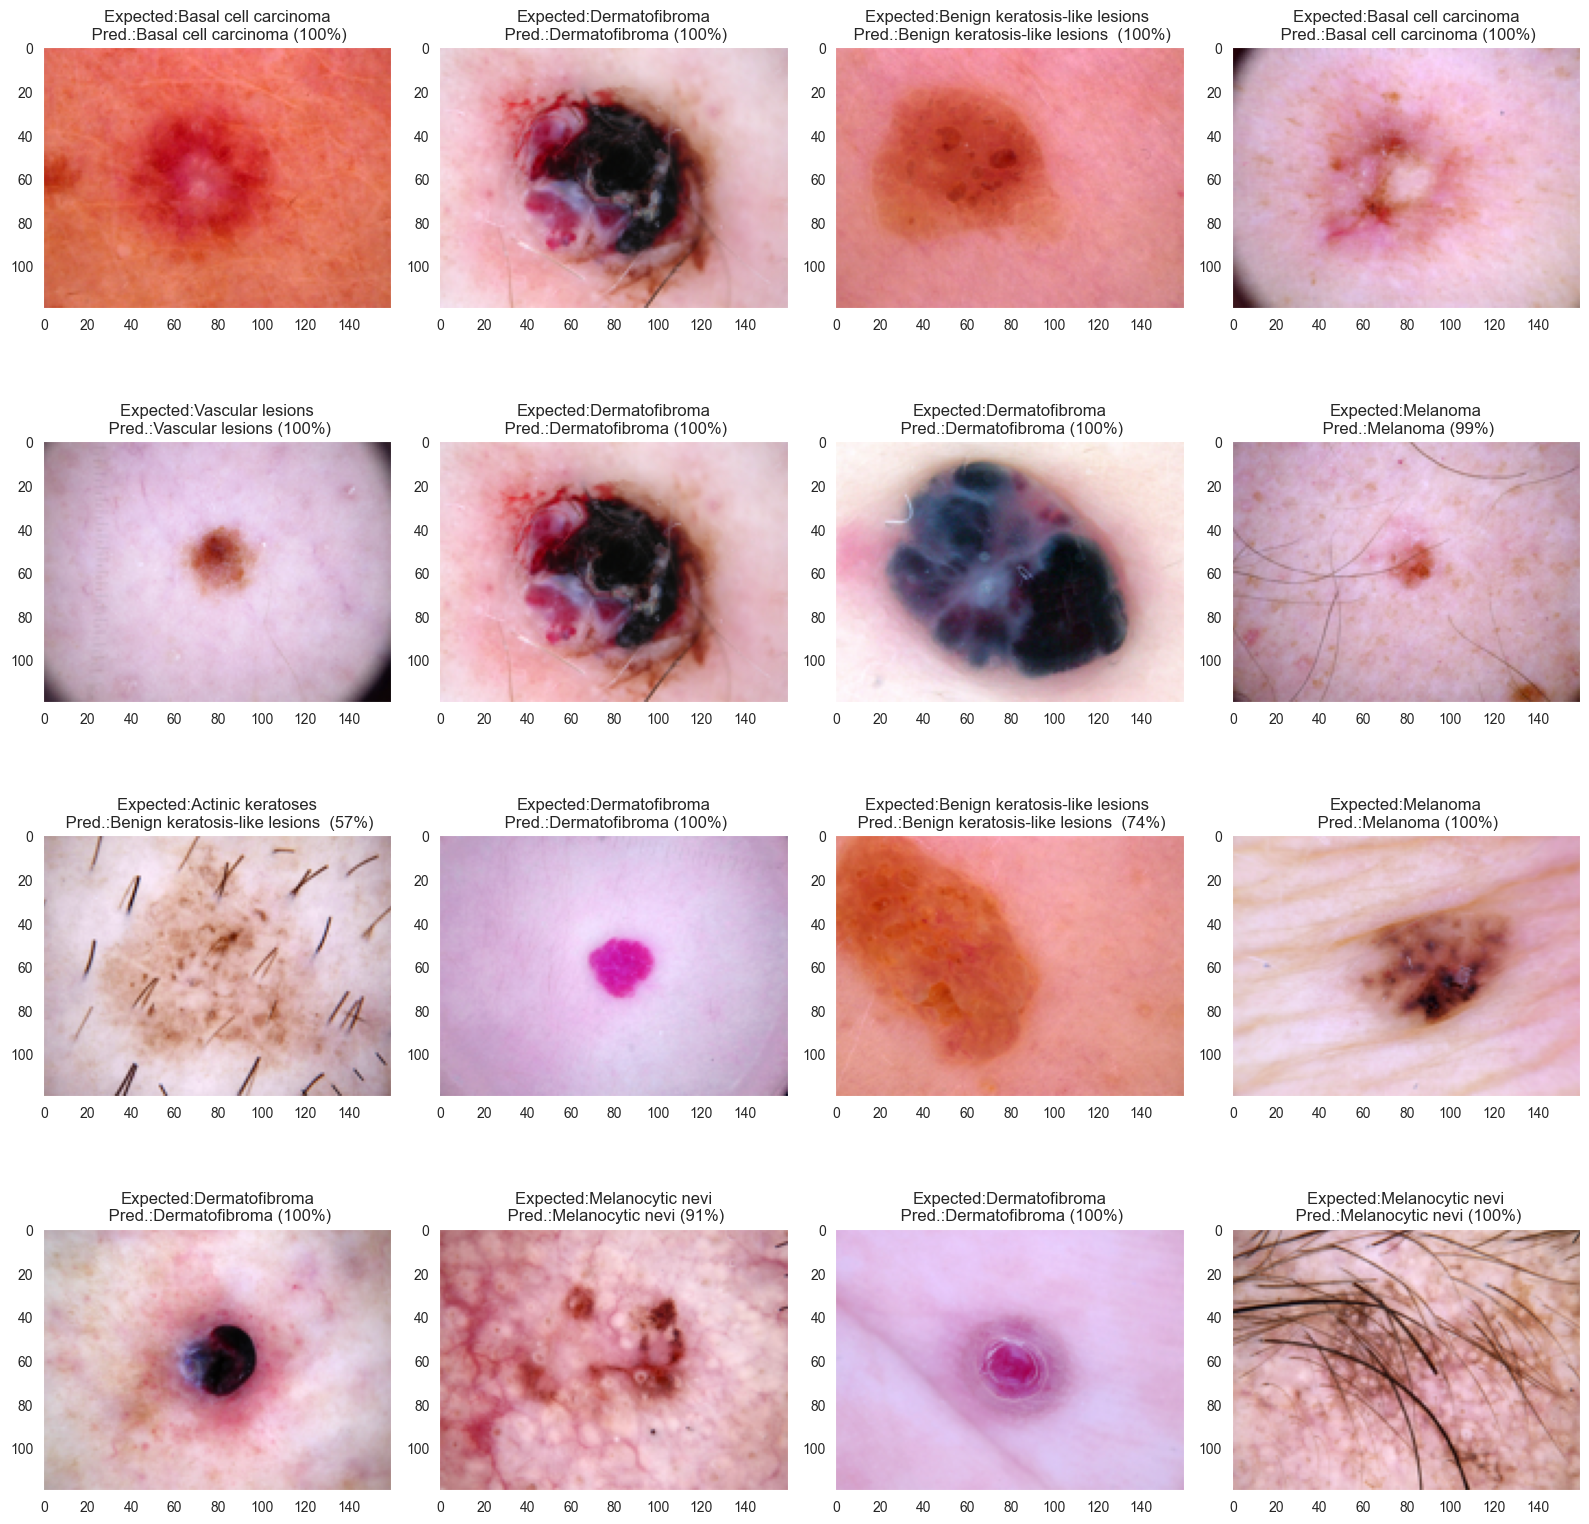

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    index = i + 100
    image_rgb = x_test[index].astype(np.float32)  # Convert image to float32
    image_rgb = (image_rgb - np.min(image_rgb)) / (np.max(image_rgb) - np.min(image_rgb))  # Normalize to 0-1 range
    plt.imshow(image_rgb)
    label_exp = lesion_names[y_true[index]]  # Expected label
    label_pred = lesion_names[y_pred[index]]  # Predicted label
    label_pred_prob = round(np.max(y_pred_prob[index]) * 100)
    plt.title('Expected:' + str(label_exp) + '\n Pred.:' + str(label_pred) + ' (' + str(label_pred_prob) + '%)')
    plt.grid(False)  # Remove grid
plt.ylabel('')
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_true, y_pred, target_names=targetNames, output_dict=True)

data = []
for class_name, metrics in report.items():
    if class_name != 'accuracy':  # Exclude accuracy metric
        data.append({
            'Class': class_name,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1-score'],
            'Support': metrics['support']
        })

df = pd.DataFrame(data)
df.to_csv('../models/Reports/vgg_adam_111_classification_report.csv', index=False)

In [45]:
print(df.to_string(index=False))

                        Class  Precision   Recall  F1-Score  Support
            Actinic keratoses   0.928571 0.910000  0.919192      100
         Basal cell carcinoma   0.916667 0.846154  0.880000       91
Benign keratosis-like lesions   0.756522 0.783784  0.769912      111
               Dermatofibroma   0.918367 1.000000  0.957447       90
             Melanocytic nevi   0.880000 0.717391  0.790419       92
                     Melanoma   0.722222 0.812500  0.764706       96
             Vascular lesions   0.983607 1.000000  0.991736      120
                    macro avg   0.872279 0.867118  0.867630      700
                 weighted avg   0.873181 0.870000  0.869669      700


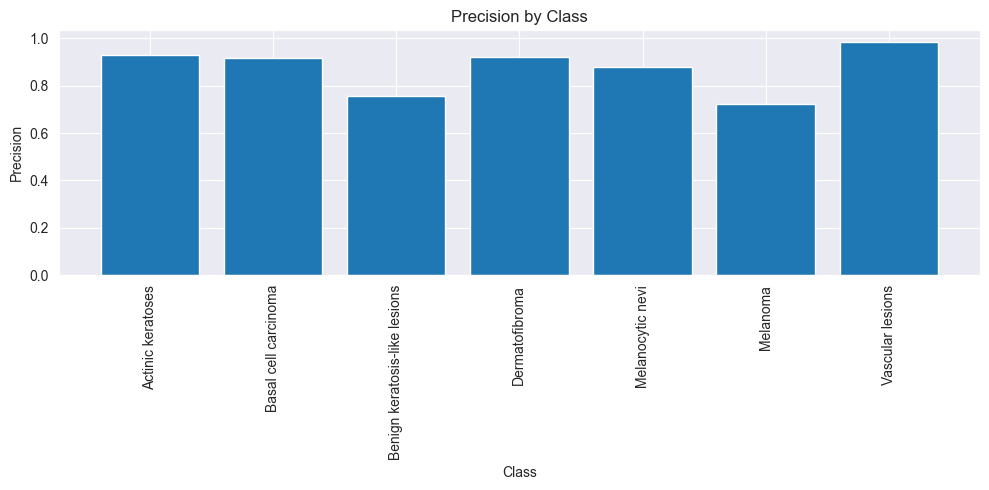

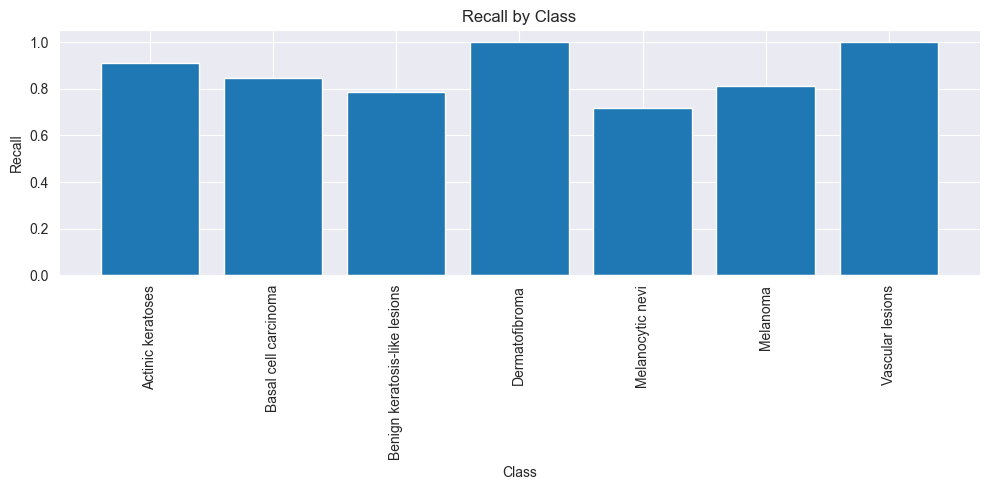

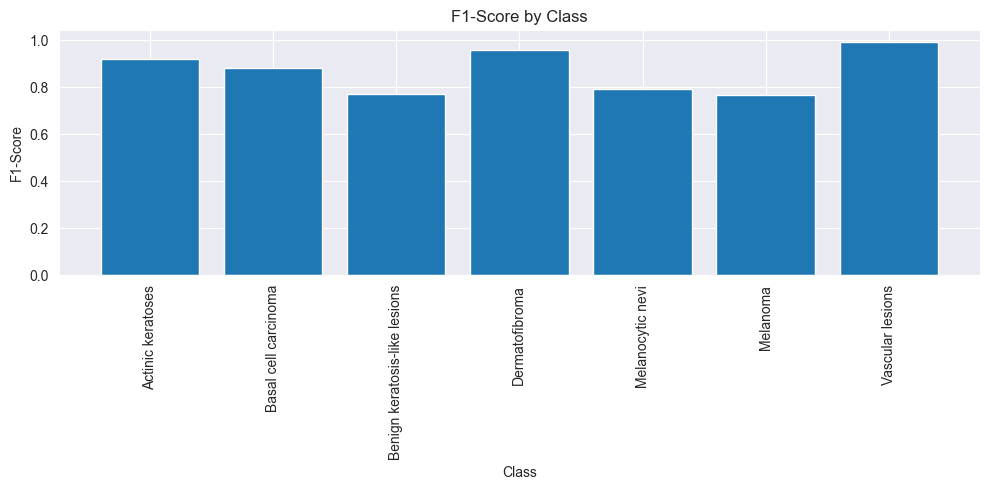

In [46]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(y_true, y_pred, target_names=targetNames, output_dict=True)

data = []
for class_name, metrics in report.items():
    if class_name != 'accuracy' and class_name in targetNames[:7]:
        data.append({
            'Class': class_name,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1-score'],
            'Support': metrics['support']
        })

df = pd.DataFrame(data)

# Plot Precision
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['Precision'])
plt.xlabel('Class')
plt.ylabel('Precision')
plt.title('Precision by Class')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot Recall
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['Recall'])
plt.xlabel('Class')
plt.ylabel('Recall')
plt.title('Recall by Class')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot F1-Score
plt.figure(figsize=(10, 5))
plt.bar(df['Class'], df['F1-Score'])
plt.xlabel('Class')
plt.ylabel('F1-Score')
plt.title('F1-Score by Class')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

df.to_csv('../models/Reports/vgg_adam_111_classification_report.csv', index=False)